# Carset

Датасет содержит подробную информацию об автомобилях, которую продавцы заполняют при подаче объявления по всем регионам США.

Основная цель этого датасета — предиктивное моделирование стоимости автомобилей на основе их характеристик.

## Импорт файла и библиотек

In [1]:
import kagglehub
import shutil
import os

path = kagglehub.dataset_download("austinreese/craigslist-carstrucks-data")

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv(os.path.join(path, "vehicles.csv"))

## Обозначения и решения

### Target encoding

1. *region* - название рынка
2. *model* - модель автомобиля 
3. *manufacturer* - производитель автомобиля

### One-Hot encoding

4. *title_status* - юридический статус автомобиля 
5. *transmission* - тип коробки передач 
6. *condition* - состояние автомобиля 
7. *paint_color* - цвет автомобиля 
8. *type* - тип автомобиля 
9. *drive* - тип привода 
10. *fuel* - тип топлива

### Delete

11. *posting_date* - дата публикации объявления 
12. *image_url* - ссылка на изображение
13. *county* - административный округ
14. *posting_date* - дата публикации
15. *VIN* - вин номер автомобиля
16. *size* - размер автомобиля
17. *id* - номер объявления
18. *state* - штат

### Other

19. *description* - описание автомобиля (TfidfVectorizer)
20. *odometer* - пробег
21. *cylinders* - количество цилиндров в двигателе
22. *lat/long* - широта и долгота

In [4]:
df.shape

(426880, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [6]:
df.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

## Исследования и работа с выбросами

In [7]:
df_corr = df.corr(numeric_only=True)["price"].sort_values(ascending=False)
df_corr

price       1.000000
odometer    0.010032
lat         0.000357
long       -0.000408
id         -0.002779
year       -0.004925
county           NaN
Name: price, dtype: float64

### `odometer`

<Axes: xlabel='odometer'>

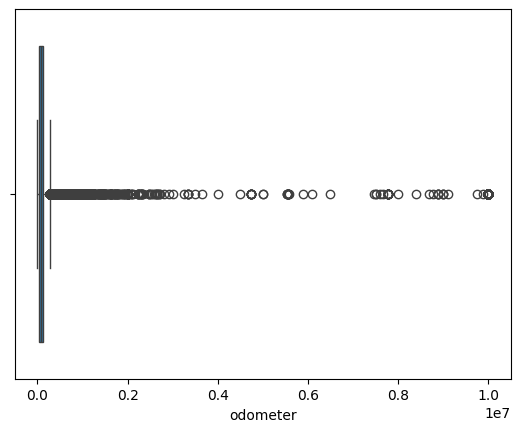

In [8]:
sns.boxplot(data=df, x="odometer")

Лимит: 277300.25
Осталось строк: 418095


<Axes: xlabel='odometer'>

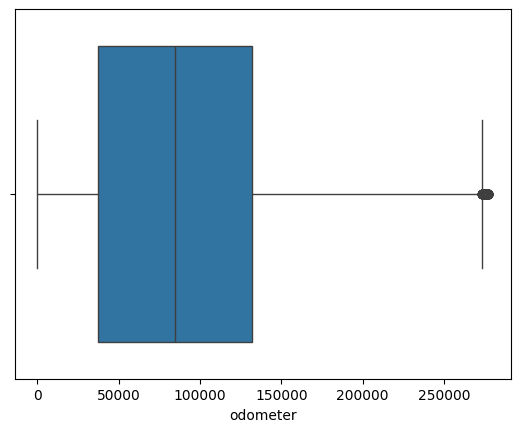

In [9]:
Q1, Q3 = np.nanpercentile(df["odometer"], [25, 75])
IQR = Q3 - Q1
higher_limit = Q3 + 1.5 * IQR

df = df[df["odometer"] < higher_limit]

print(f"Лимит: {higher_limit}")
print(f"Осталось строк: {df.shape[0]}")
sns.boxplot(data=df, x="odometer")


### `year`

<Axes: xlabel='year'>

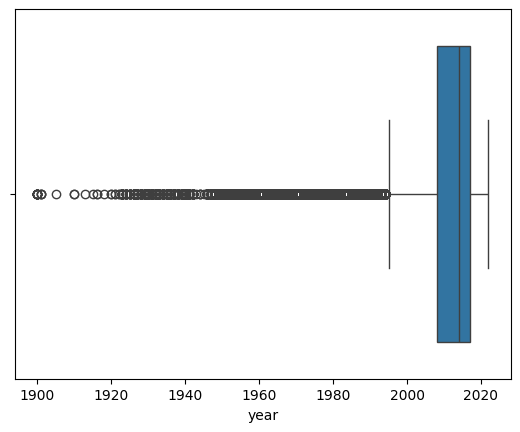

In [10]:
sns.boxplot(data=df, x="year")

Лимит: 1994.5
Осталось строк: 401711


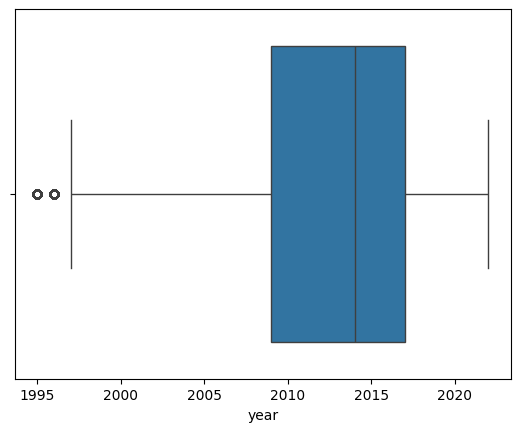

In [11]:
Q1, Q3 = np.nanpercentile(df["year"], [25, 75])
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
df = df[df["year"] > lower_limit]
sns.boxplot(data=df, x="year")

print(f"Лимит: {lower_limit}")
print(f"Осталось строк: {df.shape[0]}")

### `price`

<Axes: xlabel='price'>

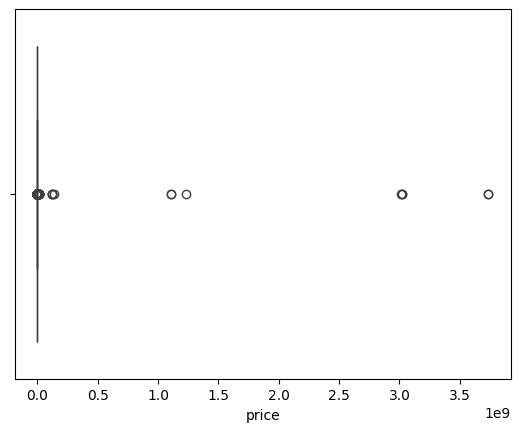

In [12]:
df["price"].describe()

sns.boxplot(data=df, x="price")

In [13]:
print(len(df[(df["price"] < 1000)]))

42635


In [14]:
print(len(df[(df["price"] > 500) & (df["price"] < 1000)]))

2881


In [15]:
print(len(df[(df["price"] > 100000)]))

552


In [16]:
df = df[(df["price"] > 1000) & (df["price"] < 100000)]

Исследование показывает, что границы в 1000 и 100000 долларов являются приемлемыми для чистки от выбросов

Осталось строк: 357453


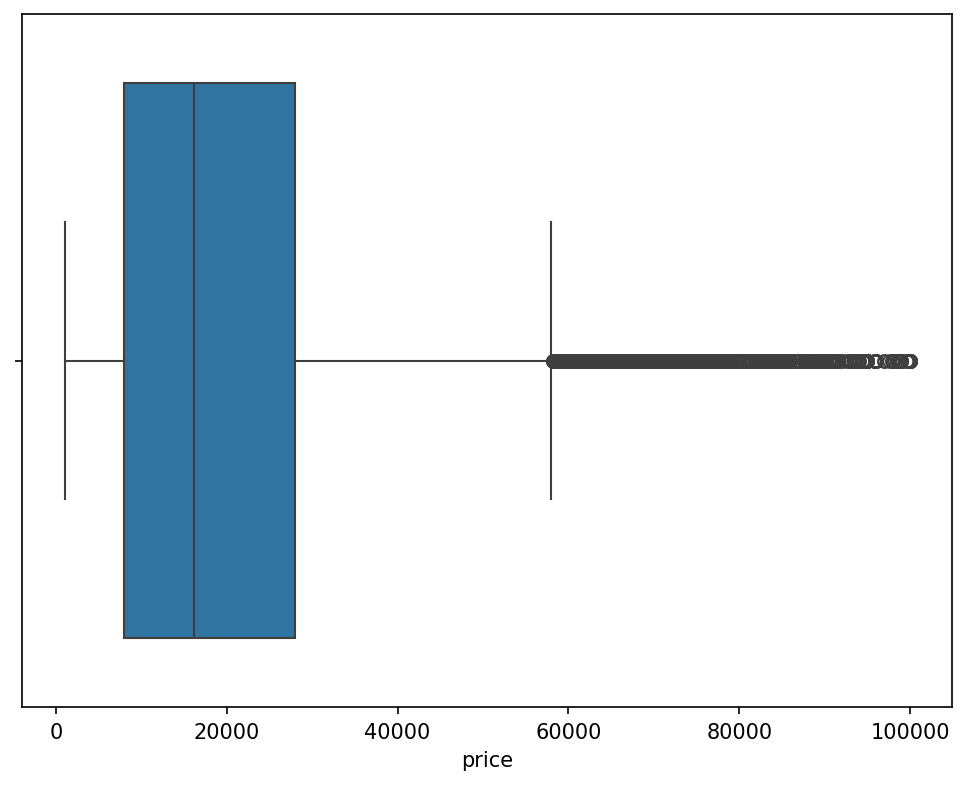

In [17]:
print(f"Осталось строк: {df.shape[0]}")

plt.figure(figsize=(8,6), dpi=150)
sns.boxplot(data=df, x="price")
plt.show();

In [18]:
state_df = df.dropna(subset=['state']).copy()

state_df['state'] = state_df['state'].str.upper()

grouped_states = state_df.groupby('state')['price'].mean().reset_index()

fig = px.choropleth(
    grouped_states, 
    locations="state",          
    locationmode="USA-states",  
    color="price",              
    scope="usa",                
    color_continuous_scale="Turbo",
    title="Mean price in the USA in 2021"
)

# fig.update_layout(margin={"r":0, "t":40, "l":0, "b":0})
fig.show()

### `posting_date`, `state` and other

In [19]:
pd.to_datetime(df['posting_date'], utc=True).dt.year.unique()

array([2021], dtype=int32)

Наиболее логичным было бы оставить только год публикации объявления, однако все объявления были сделаны в 2021 году, следовательно столбец `posting_date` можно удалить, как и ссылки, широту, долготу и другие.

Столбец `state` по сути дублирует `region`, однако более информативным столбцом является второй

In [20]:
del_col = ["url", "region_url", "county", "image_url", "lat", "long", "state", "posting_date"]
df = df.drop(del_col, axis=1).set_index("id")

In [21]:
df.corr(numeric_only=True)['price']

price       1.000000
year        0.606788
odometer   -0.558187
Name: price, dtype: float64

Используя знания из предметной области, можно сделать вывод: корреляция выглядит естественно.

### Работа с пропусками

In [23]:
def found_miss(df):
  percent_na = np.round(100 * df.isna().sum() / len(df), 2)

  return percent_na[percent_na > 0].sort_values()

C:\Users\egoro\AppData\Local\Temp\ipykernel_14452\3739375903.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




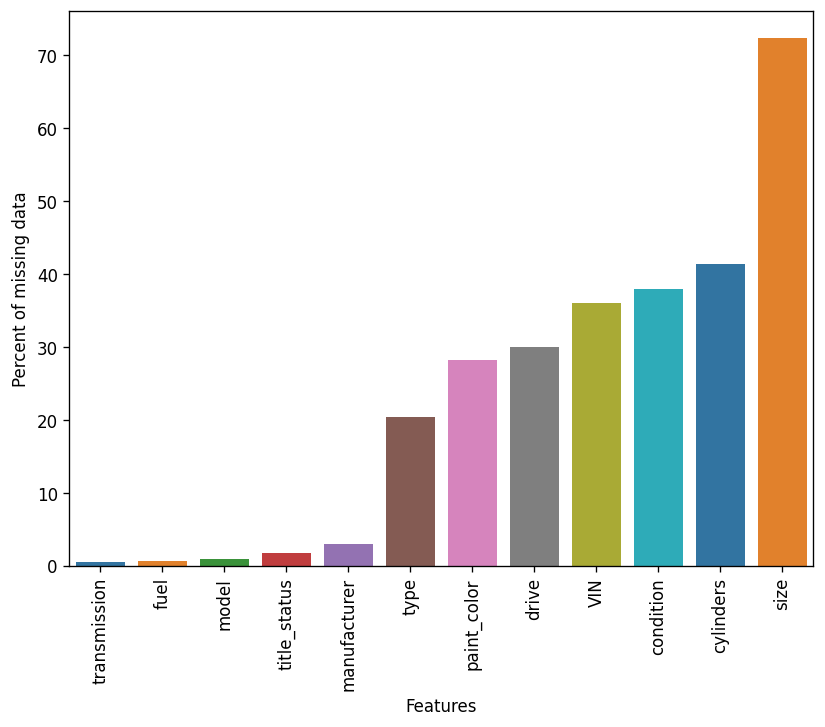

In [24]:
plt.figure(figsize=(8,6), dpi=120);
sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");
plt.xlabel("Features");
plt.ylabel("Percent of missing data");
plt.xticks(rotation=90);
plt.show();

C:\Users\egoro\AppData\Local\Temp\ipykernel_14452\605149035.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




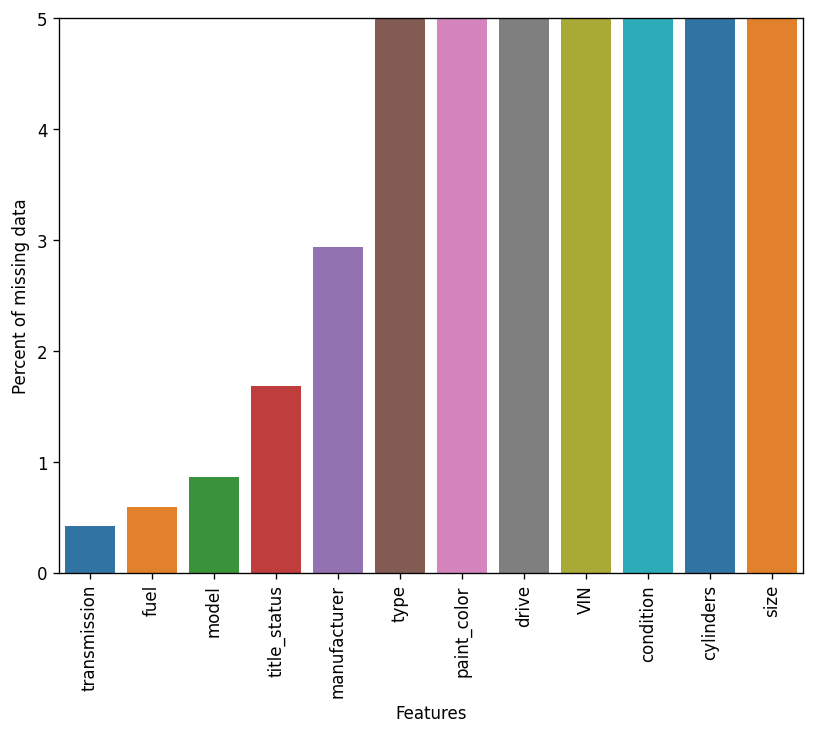

In [25]:
plt.figure(figsize=(8,6), dpi=120);
plt.ylim(0,5)
sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");
plt.xlabel("Features")
plt.ylabel("Percent of missing data")
plt.xticks(rotation=90);
plt.show();

### `transmission`

In [26]:
def fill_mode(x):
    row = x.mode()
    if not row.empty:
        return x.fillna(row[0])
    else:
        return x

In [27]:
print(f"Before:{df["transmission"].isna().sum()}")
df["transmission"] = df.groupby(["manufacturer", "model"], dropna=False)["transmission"].transform(fill_mode)
print(f"After:{df["transmission"].isna().sum()}")
df = df.dropna(subset=["transmission"])

Before:1485
After:64


### `fuel`

In [28]:
print(f"Before:{df["fuel"].isna().sum()}")
df["fuel"] = df.groupby(["manufacturer", "model"], dropna=False)["fuel"].transform(fill_mode)
print(f"After:{df["fuel"].isna().sum()}")
df["fuel"] = df["fuel"].fillna("gas")

Before:2096
After:1395


### `model`

Используя знания из предметной области, делаем вывод: в первых 8-ми числах VIN номера содержится информация о производителе и модели автомобиля.

In [29]:
df_copy = df.copy()
df_copy["pattern_vin"] = df["VIN"].str[:8]

In [30]:
df_copy["model"] = df_copy.groupby("pattern_vin", dropna=False)["model"].transform(fill_mode)
print(f"Пропущено: {df_copy["model"].isna().sum()}")
df_copy = df_copy.dropna(subset=["model"])

Пропущено: 193


In [31]:
df_copy["model"] = df_copy["model"].str.lower().str.strip()
freq = df_copy["model"].value_counts()
freq = freq[freq >= 150].index
df_copy["model"] = df_copy["model"].where(df_copy["model"].isin(freq), "other")

In [32]:
df_copy["model"].value_counts()

model
other                       158306
f-150                         8571
silverado 1500                4223
1500                          3684
camry                         2623
                             ...  
corvette stingray              151
pilot ex-l                     150
fiesta se                      150
s5 premium plus sedan 4d       150
q50 3.0t luxe sedan 4d         150
Name: count, Length: 391, dtype: int64

Количество моделей, определённых как "other", слишком велико, к тому же менее распространённые модели содержат лишние символы, поэтому лучше модель определять по первому слову из одноимённой колонки.

In [33]:
df["model"] = df["model"].str.split().str[0].str.lower()

freq = df["model"].value_counts()
good_models = freq[freq >= 150].index

df["model"] = df["model"].where(df["model"].isin(good_models), "other")

df["model"].value_counts()

model
other        34243
silverado    14515
f-150         8457
1500          8051
sierra        7290
             ...  
captiva        157
f              156
rx350          154
cla            152
land           151
Name: count, Length: 308, dtype: int64

### `title_status`

In [34]:
print(df["title_status"].isna().sum())
df["title_status"] = df["title_status"].fillna("Unknown")

5997


### `manufacturer`

In [35]:
print(f"Before:{df["manufacturer"].isna().sum()}")
df["manufacturer"] = df.groupby("model", dropna=False)["manufacturer"].transform(fill_mode)
print(f"After: {df["manufacturer"].isna().sum()}")

Before:10485
After: 2529


In [36]:
df["pattern_vin"] = df["VIN"].str[:8]
print(f"Before:{df["manufacturer"].isna().sum()}")
df["manufacturer"] = df.groupby("pattern_vin", dropna=False)["manufacturer"].transform(fill_mode)
print(f"After: {df["manufacturer"].isna().sum()}")
df = df.dropna(subset=["manufacturer"])

Before:2529
After: 1010


<Axes: xlabel='manufacturer', ylabel='count'>

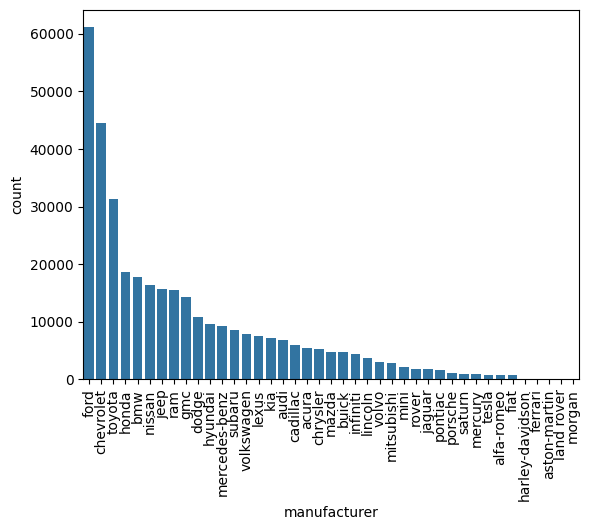

In [37]:
manufacturer_values = df["manufacturer"].value_counts().index
plt.xticks(rotation=90)
sns.countplot(x= df["manufacturer"], order=manufacturer_values)

In [38]:
print(df["manufacturer"].unique())

['gmc' 'chevrolet' 'toyota' 'ford' 'jeep' 'nissan' 'ram' 'mazda'
 'cadillac' 'honda' 'dodge' 'lexus' 'jaguar' 'buick' 'chrysler' 'volvo'
 'audi' 'infiniti' 'lincoln' 'alfa-romeo' 'subaru' 'acura' 'hyundai'
 'mercedes-benz' 'bmw' 'mitsubishi' 'volkswagen' 'porsche' 'kia' 'rover'
 'ferrari' 'mini' 'pontiac' 'fiat' 'tesla' 'saturn' 'mercury'
 'harley-davidson' 'aston-martin' 'land rover' 'morgan']


### `size`

In [39]:
df = df.drop("size", axis=1)

### `type`

C:\Users\egoro\AppData\Local\Temp\ipykernel_14452\2374350663.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




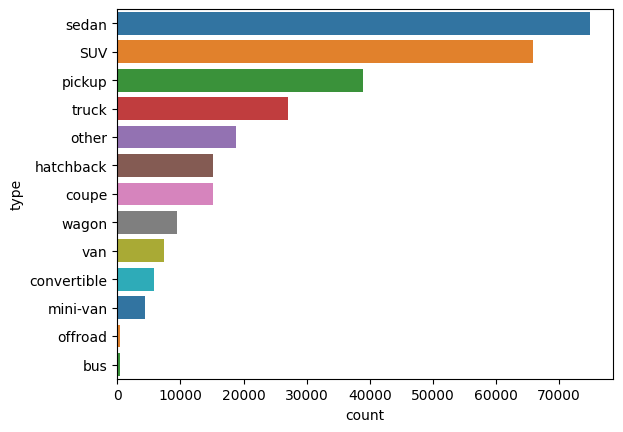

In [40]:
sns.countplot(df["type"], palette="tab10", order=df["type"].value_counts().index);

In [41]:
print(f"Before:{df["type"].isna().sum()}")
df["type"] = df.groupby(["manufacturer", "model"], dropna=False)["type"].transform(fill_mode)
print(f"After manufacturer and model:{df["type"].isna().sum()}")
df["type"] = df.groupby(["model", "drive"], dropna=False)["type"].transform(fill_mode)
print(f"After model and drive:{df["type"].isna().sum()}")
df["type"] = df["type"].fillna(df["type"].mode()[0])

Before:72611
After manufacturer and model:21
After model and drive:0


### `paint_color`

In [42]:
print(f"Before:{df["paint_color"].isna().sum()}")
df["paint_color"] = df["paint_color"].fillna(df["paint_color"].mode()[0])
print(f"After:{df["paint_color"].isna().sum()}")

Before:100537
After:0


### `VIN`

In [43]:
df = df.drop(["VIN", "pattern_vin"], axis=1)

### `drive`

In [44]:
print(f"Before:{df["drive"].isna().sum()}")
df["drive"] = df.groupby(["manufacturer", "model"], dropna=False)["drive"].transform(fill_mode)
print(f"After manufacturer and model:{df["drive"].isna().sum()}")
df["drive"] = df["drive"].fillna(df["drive"].mode()[0])
print(f"After filling with drive:{df["drive"].isna().sum()}")

Before:107000
After manufacturer and model:27
After filling with drive:0


### `condition`

C:\Users\egoro\AppData\Local\Temp\ipykernel_14452\2136004087.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




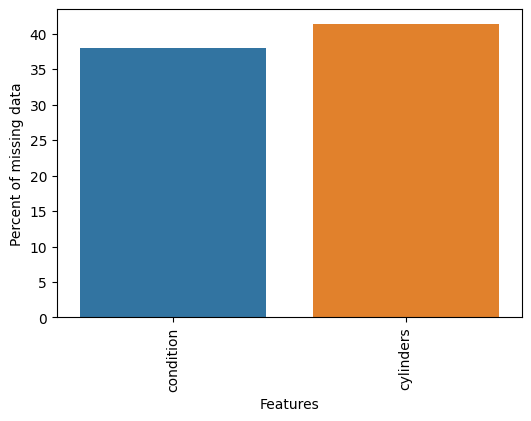

In [ ]:
plt.figure(figsize=(6,4), dpi=100);
sns.barplot(x=found_miss(df).index, y=found_miss(df), palette="tab10");
plt.xlabel("Features")
plt.ylabel("Percent of missing data")
plt.xticks(rotation=90)
plt.show();

In [46]:
df["condition"].unique()

array(['good', 'excellent', 'fair', 'like new', nan, 'new', 'salvage'],
      dtype=object)

In [47]:
bondaries = [0, 6000, 20000, 60000, 100000, 180000, np.inf]
names = ["new", "like new", "excellent", "good", "fair", "salvage"]
odomet_cond = pd.cut(df["odometer"], bins=bondaries, labels=names).astype("str")
df["condition"] = df["condition"].fillna(odomet_cond)

### `cylinders`

In [48]:
df["cylinders"] = df.groupby("model", dropna=False)["cylinders"].transform(fill_mode)
df["cylinders"] = df.groupby("type", dropna=False)["cylinders"].transform(fill_mode)

In [49]:
df["cylinders"] = df["cylinders"].str.split().str[0]
df["cylinders"] = pd.to_numeric(df["cylinders"], errors="coerce")
df["cylinders"] = df["cylinders"].fillna(df["cylinders"].median())

<Axes: xlabel='cylinders'>

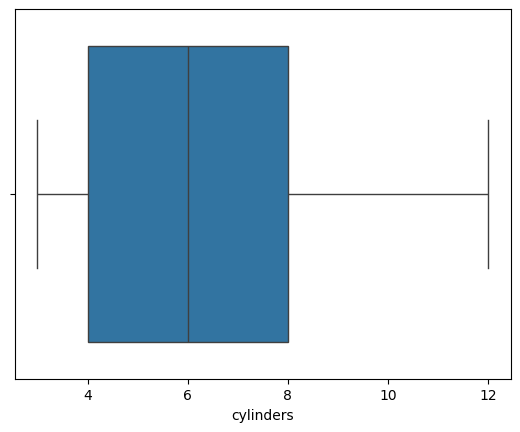

In [50]:
sns.boxplot(data=df, x="cylinders")

In [51]:
df.isna().sum()

region          0
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
description     2
dtype: int64

In [52]:
df = df.dropna()

<Axes: >

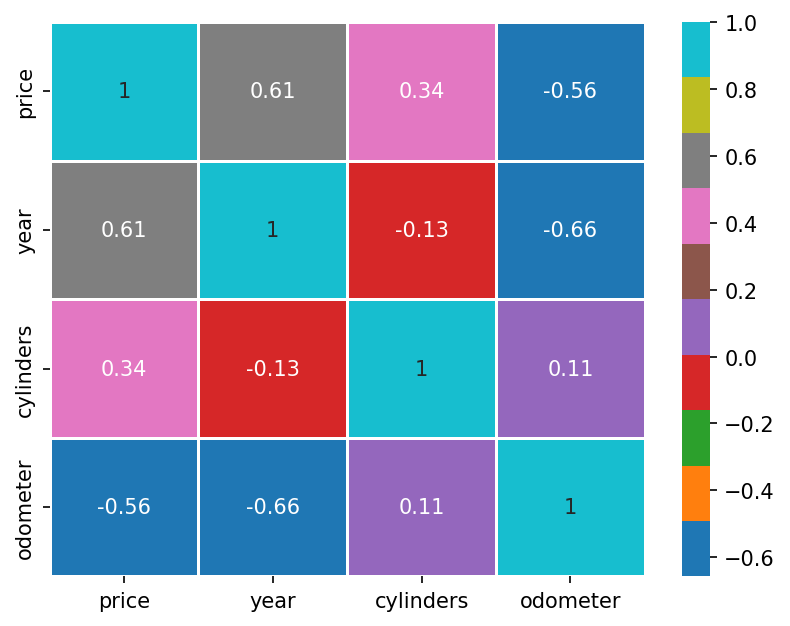

In [53]:
plt.figure(dpi=150)
sns.heatmap(data=df.corr(numeric_only=True), annot=True, lw=0.5, cmap="tab10")

Зависимость между `year` и `odometer` велика (-0.66), что может повлиять на результат работы линейных алгоритмов.

In [54]:
len(df)

356377

In [55]:
df.columns.tolist()

['region',
 'price',
 'year',
 'manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel',
 'odometer',
 'title_status',
 'transmission',
 'drive',
 'type',
 'paint_color',
 'description']

Колонки `region`, `manufacturer` и `model` содержат много уникальных значений, поэтому в целях экономии памяти было решено применить **TargetEncoding** после разбиения на тестовую, валидационную и тренировочную выборки. К колонке `description` применим алгоритм **NLP**

In [56]:
print(f"Количество моделей: {len(df["model"].unique())}\nКоличество регионов: {len(df["region"].unique())}\nКоличество марок автомобиля: {len(df["manufacturer"].unique())}")

Количество моделей: 308
Количество регионов: 404
Количество марок автомобиля: 41


In [57]:
list_dummies = ["drive", "title_status", "fuel", "condition", "paint_color", "type", "transmission"]
for column in list_dummies:
    df = pd.get_dummies(df, columns=[column], drop_first=True, dtype="int")

In [58]:
len(df.columns)

51

## Supervised Learning

In [59]:
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from category_encoders import TargetEncoder
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from supertree import SuperTree

### Подготовка признаков и целевой переменной

In [60]:
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_other, y_train, y_other = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
tfidf = TfidfVectorizer(max_features=50, stop_words='english')

matrix_train = tfidf.fit_transform(X_train["description"])
matrix_test = tfidf.transform(X_other["description"])

df_matrix_train = pd.DataFrame(matrix_train.toarray(), columns=tfidf.get_feature_names_out(), index=X_train.index)
df_matrix_other = pd.DataFrame(matrix_test.toarray(), columns=tfidf.get_feature_names_out(), index=X_other.index)

X_train = pd.concat([X_train, df_matrix_train], axis=1)
X_other = pd.concat([X_other, df_matrix_other], axis=1)

X_train = X_train.drop("description", axis=1)
X_other = X_other.drop("description", axis=1)

In [62]:
X_valid, X_test, y_valid, y_test = train_test_split(X_other, y_other, test_size=0.5, random_state=42)

In [63]:
encoder = TargetEncoder(cols=['model', 'region', 'manufacturer'])

X_train = encoder.fit_transform(X_train, y_train)

X_valid = encoder.transform(X_valid)

X_test = encoder.transform(X_test)

mean_price = y_valid.mean()

### Linear Regression

In [64]:
lin_pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("linear", LinearRegression(n_jobs=6))
])

lin_pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('linear', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,6


In [65]:
y_pred = lin_pipe.predict(X_valid)

In [66]:
from sklearn.metrics import root_mean_squared_error

RMSE = root_mean_squared_error(y_valid, y_pred)

print(f"Error of LR - {RMSE/mean_price*100:.2f}%")

Error of LR - 36.03%


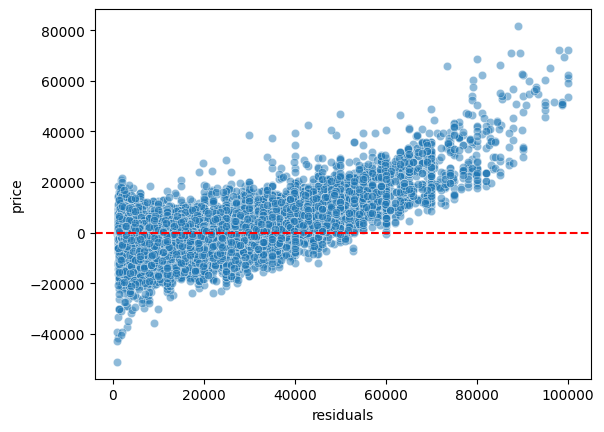

In [67]:
residuals = y_valid - lin_pipe.predict(X_valid)

sns.scatterplot(x=y_valid, y=residuals, alpha=0.5)
plt.xlabel("residuals")
plt.axhline(y=0, color="red", ls="--")

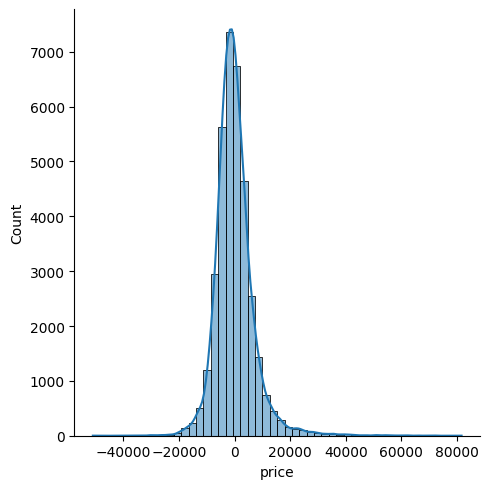

In [68]:
sns.displot(x=residuals, bins=50, kde=True)

### Отчётность по первой модели линейной регрессии

График остатков показывает, что модель линейной регрессии не подходит для датасета, что делает бессмысленным дальнейший подбор гиперпараметров для базовых линейных алгоритмов; также полиномиальная регрессия здесь не допустима ввиду большого количества признаков.

Однако возможным решением будет логарифмирование целевой переменной из-за эффекта "расширяющейся воронки". 

In [69]:
y_train_log = np.log1p(y_train)

lin_pipe.fit(X_train, y_train_log)
y_pred = np.expm1(lin_pipe.predict(X_valid))

RMSE = root_mean_squared_error(y_valid, y_pred)

print(f"Error of LR: {RMSE/mean_price*100:.2f}%")

Error of LR: 36.70%


Логарифмирование не исправило ситуацию.

### Lasso


Чтобы определить, вызвана ли высокая ошибка модели недообучением или переобучением на большом количестве признаков, была протестирована **Lasso-регуляризация**; данный тип регуляризации был выбран по причине наличия большого количества признаков, а одним из свойством данного типа является зануление коллинеарных признаков.

In [70]:
lasso_pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("lasso_model", LassoCV(cv=10, max_iter=2000, eps=0.0001, n_jobs=6, random_state=42))
])

lasso_pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('lasso_model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,eps,0.0001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True


In [71]:
y_pred = lasso_pipe.predict(X_valid)

RMSE = root_mean_squared_error(y_valid, y_pred)

print(f"Error of Lasso - {RMSE/mean_price*100:.2f}%")

Error of Lasso - 36.03%


### SVM

In [72]:
from sklearn.metrics import get_scorer_names

name_scores = get_scorer_names()
print(name_scores)

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_macro', 'recall_micro', 'recall_samples'

In [73]:
SVR_pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("SVR", LinearSVR(dual=False,loss='squared_epsilon_insensitive', random_state=42))
])

param_grid = {
    "SVR__C": [0.01, 0.1, 1, 10],
    "SVR__epsilon": [0.01, 0.1, 0.2],
    "SVR__max_iter": [3000]
}

SVR_grid_model = GridSearchCV(SVR_pipe, param_grid=param_grid, cv=5, verbose=1, scoring="neg_root_mean_squared_error", n_jobs=6)
SVR_grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'SVR__C': [0.01, 0.1, ...], 'SVR__epsilon': [0.01, 0.1, ...], 'SVR__max_iter': [3000]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,6
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,feature_range,"(0, ...)"


In [74]:
y_pred = SVR_grid_model.predict(X_valid)

RMSE = root_mean_squared_error(y_valid, y_pred)

print(f"Error of SVR: {RMSE/mean_price*100:.2f}%")

Error of SVR: 36.03%


Качество **LinearSVR** находится на уровне базовой линейной регрессии, что окончательно подтверждает отсутствие линейных зависимостей.

**Алгоритм KNN** здесь не применим ввиду размерности.

### Random Forest

In [ ]:
RF_model = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 150],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True],
    "max_depth": [10, 15, 20]
}

RF_grid_model = GridSearchCV(RF_model, param_grid=param_grid, scoring="neg_root_mean_squared_error", cv=5, verbose=1, n_jobs=6)
RF_grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'RF_model__bootstrap': [True], 'RF_model__max_depth': [10, 15, ...], 'RF_model__max_features': ['sqrt', 'log2'], 'RF_model__n_estimators': [100, 150]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,6
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,feature_range,"(0, ...)"


In [76]:
y_pred = RF_grid_model.best_estimator_.predict(X_valid)

RMSE = root_mean_squared_error(y_valid, y_pred)

print(f"Error of RF: {RMSE/mean_price*100:.2f}%")

Error of RF: 20.59%


In [77]:
RF_grid_model.best_estimator_["RF_model"].get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 20,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 150,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

**Random Forest** показал хороший результат.

### Gradient Boosting

In [ ]:
from scipy.stats import uniform

grad_model = HistGradientBoostingRegressor(random_state=42)

param_grid = {
    "max_iter": [150, 200],
    "learning_rate": uniform(0.05, 0.05),
    "max_depth": [3, 5, 7]
}

grad_grid_model = RandomizedSearchCV(grad_model, param_distributions=param_grid, cv=5, verbose=1, n_jobs=6, scoring="neg_root_mean_squared_error", n_iter=15, random_state=42)
grad_grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'grad_model__learning_rate': <scipy.stats....002B4EE895850>, 'grad_model__max_depth': [3, 5, ...], 'grad_model__max_iter': [150, 200]}"
,n_iter,15
,scoring,'neg_root_mean_squared_error'
,n_jobs,6
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [80]:
y_pred = grad_grid_model.predict(X_valid)

RMSE = root_mean_squared_error(y_valid, y_pred)

print(f"Error of Gradient Boosting: {RMSE/mean_price*100:.2f}%")

Error of Gradient Boosting: 24.44%


### Отчёт по обучению с учителем

Модель случайного леса показала лучшие результаты, однако стоит заметить, что в градиентном бустинге был использован RandomizedSearchCV, поэтому лучшие параметры могли быть пропущены.

## Unsupervised + supervised learning

С помощью кластеризации можно добавить еще колонки признаков, поскольку леса не всегда улавливают скрытые зависимости между признаками.

In [64]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### K-means

In [65]:
SSD = []
scaler = MinMaxScaler()
X_train_scale = scaler.fit_transform(X_train)
X_valid_scale = scaler.transform(X_valid)
X_all = np.vstack([X_train_scale, X_valid_scale])

for n in range(2,20):
    KM_model = KMeans(n_clusters=n, random_state=42)
    KM_model.fit(X_all)
    SSD.append(KM_model.inertia_)

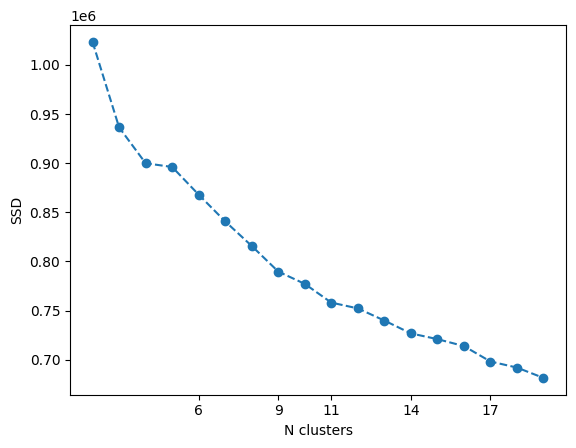

In [ ]:
plt.plot(np.arange(2, 20), pd.Series(SSD), "--o")
plt.ylabel("SSD")
plt.xlabel("N clusters")
plt.xticks([4, 9, 11, 14, 17])
plt.show();

По методу локтя трудно определить подходящее число кластеров, однако в качестве основы можно их использовать в методе силуэтов.

In [ ]:
list_k_cluster = [9, 14, 17]
silhouettes = []

for i in list_k_cluster:
    KM_model = KMeans(n_clusters=i, random_state=42)
    KM_model.fit(X_all)

    silhouettes.append(silhouette_score(X_all, KM_model.labels_, sample_size=100000, random_state=42))

In [85]:
print(silhouettes)

[0.08976481333003523, 0.0967366604693292, 0.09412483231067173]


Метод силуэтов показывает низкие результаты, однако в связке с новым признаком новая колонка кластеризации может улучшить результат.

### Создание новых признаков

Создаем новую колонку `Cluster`

In [66]:
KM_model = KMeans(n_clusters=14)

X_train["Cluster"] = KM_model.fit_predict(X_train_scale)
X_valid["Cluster"] = KM_model.predict(X_valid_scale)
X_test["Cluster"] = KM_model.predict(scaler.transform(X_test))

Добавляем признак `Odometer/years`, обозначающий сколько машина в среднем проезжала за год.

In [67]:
X_train["Odometer/years"] = np.where(X_train["year"] == 2021, X_train["odometer"], X_train["odometer"] / (2021 - X_train["year"]))
X_valid["Odometer/years"] = np.where(X_valid["year"] == 2021, X_valid["odometer"], X_valid["odometer"] / (2021 - X_valid["year"]))
X_test["Odometer/years"]  = np.where(X_test["year"] == 2021, X_test["odometer"], X_test["odometer"] / (2021 - X_test["year"]))

In [68]:
X_train.corr(numeric_only=True)["Odometer/years"].sort_values()

carvanaauto          -0.233216
carvana              -0.229108
transmission_other   -0.221038
safety               -0.172096
car                  -0.171924
                        ...   
condition_salvage     0.137015
condition_fair        0.177158
year                  0.224963
odometer              0.413189
Odometer/years        1.000000
Name: Odometer/years, Length: 101, dtype: float64

Модель **Random Forest** показала лучший результат, поэтому следующим шагом является изменение гиперпараметров данной модели.

### Random Forest 2

In [ ]:
RF_model = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [150],
    "max_features": ["sqrt", "log2"],
    "max_depth": [20, 30],
    "bootstrap": [True]
}

RF_grid_model = GridSearchCV(RF_model, param_grid=param_grid, scoring="neg_root_mean_squared_error", cv=5, verbose=1, n_jobs=8)
RF_grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'bootstrap': [True], 'max_depth': [20, 30], 'max_features': ['sqrt', 'log2'], 'n_estimators': [150]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,8
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,150


In [ ]:
y_pred = RF_grid_model.predict(X_valid)

RMSE = root_mean_squared_error(y_valid, y_pred)

print(f"Error of RF_2: {RMSE/mean_price*100:.2f}%")

Error of RF_2: 18.54%


In [ ]:
RF_grid_model.best_params_

{'RF_model__bootstrap': True,
 'RF_model__max_depth': 30,
 'RF_model__max_features': 'sqrt',
 'RF_model__n_estimators': 150}

Ошибка уменьшилась на **2%**, что на данном этапе хороший показатель.

Финальным решением будет избавиться от признаков, вносящие минимальный вклад, на которые лес тратит сплиты.

### SHAP

In [ ]:
main_model = RandomForestRegressor(max_depth=30, n_estimators=150, max_features="sqrt", bootstrap=True)

main_model.fit(X_train, y_train)

,n_estimators,150
,criterion,'squared_error'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


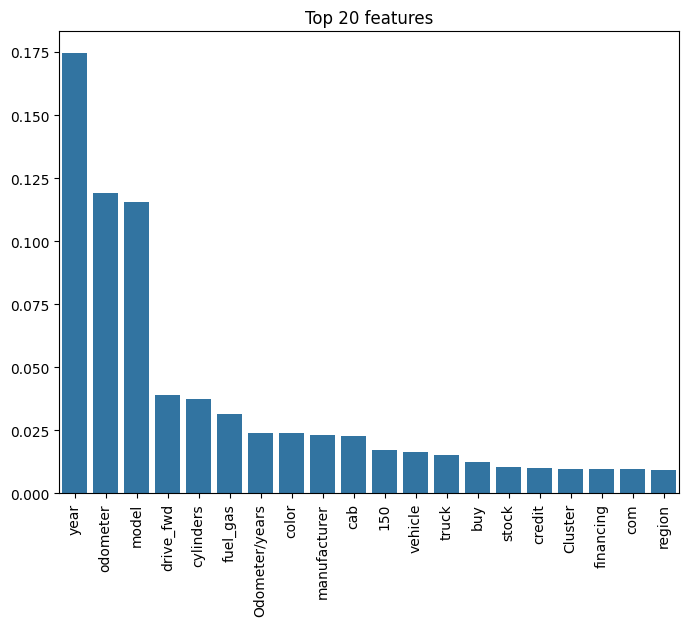

In [ ]:
importances_features = pd.Series(main_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
plt.title("Top 20 features")
plt.xticks(rotation=90)
sns.barplot(importances_features[:20])
plt.show();

In [ ]:
import shap

indices = np.random.choice(X_valid.shape[0], size=30000, replace=False)

X_sample = X_valid.iloc[indices].to_numpy()
real_names = list(X_valid.columns)

explainer = shap.TreeExplainer(main_model)

shap_values_matrix = explainer.shap_values(X_sample, approximate=True)

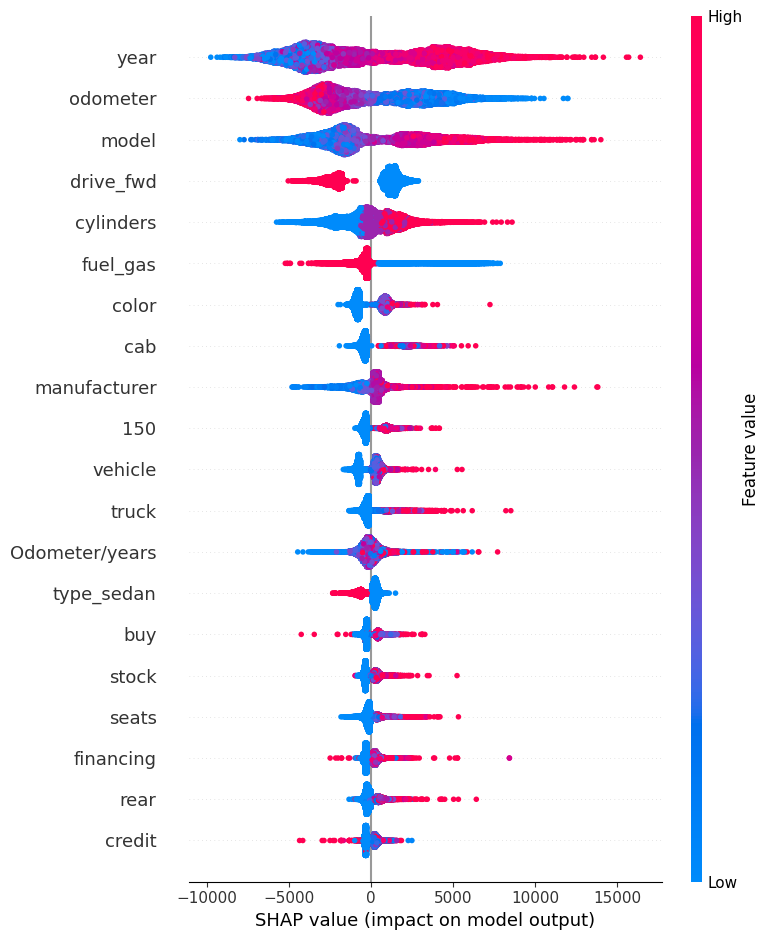

In [75]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_matrix, X_sample)

In [ ]:
mean_abs_shap = np.abs(shap_values_matrix).mean(axis=0)

shap_table = pd.DataFrame({
    'Признак': real_names,
    'SHAP-значение': mean_abs_shap
})

shap_table = shap_table.sort_values(by='SHAP-значение')

In [77]:
print("Слабые признаки")
print("-" * 50)
print(shap_table.head(10))

print("\n")

print("Сильные признаки")
print("-" * 50)
print(shap_table.tail(10))

Слабые признаки
--------------------------------------------------
                    Признак  SHAP-значение
11  title_status_parts only       0.255941
10     title_status_missing       0.303024
30       paint_color_purple       0.886637
21            condition_nan       1.053847
35                 type_bus       1.381430
40             type_offroad       1.417764
29       paint_color_orange       2.926730
34       paint_color_yellow       3.553541
26       paint_color_custom       4.815612
14            fuel_electric       5.255935


Сильные признаки
--------------------------------------------------
         Признак  SHAP-значение
49           150     560.200246
2   manufacturer     657.881082
54           cab     724.008914
61         color     880.653773
15      fuel_gas    1017.599235
4      cylinders    1235.759478
6      drive_fwd    1700.414258
3          model    2639.598289
5       odometer    2751.834278
1           year    3752.826256


9 признаков вносят вклад менее 5$.

In [ ]:
low_importance_features = shap_table[shap_table['SHAP-значение'] < 5.0]['Признак'].tolist()

X_train_final = X_train.drop(columns=low_importance_features)
X_valid_final = X_valid.drop(columns=low_importance_features)
X_test_final = X_test.drop(columns=low_importance_features)

print(f"Новый размер признакового пространства: {X_train_final.shape[1]} вместо {X_train.shape[1]}")

Новый размер признакового пространства: 92 вместо 101


In [82]:
main_model = RandomForestRegressor(max_depth=30, n_estimators=150, max_features="sqrt", bootstrap=True)

main_model.fit(X_train_final, y_train)

,n_estimators,150
,criterion,'squared_error'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
y_pred = main_model.predict(X_valid_final)

RMSE = root_mean_squared_error(y_valid, y_pred)

print(f"Error of RF_2: {RMSE/mean_price*100:.2f}%")

Error of RF_2: 18.56%


### Итог подбора гиперпараметров и удаления слабых признаков

При изменении гиперпараметров модель улучшила свой результат на валидационной выборке примерно на **2%**. При удалении слабых признаков качество снизилось незначительно (**всего на 0.01%**), однако за счёт снижения количества признаков сама модель заметно упростилась (**почти на 10%**)

## Проверка качества модели на тестовой выборке

In [84]:
y_pred = main_model.predict(X_test_final)

RMSE = root_mean_squared_error(y_test, y_pred)

print(f"Error of RF_2: {RMSE/mean_price*100:.2f}%")

Error of RF_2: 18.05%


In [85]:
from sklearn.metrics import r2_score

R2 = r2_score(y_test, y_pred)
print(f"Коэффициент детерминации R2: {R2:.4f}")

Коэффициент детерминации R2: 0.9369


### Итог проверки качества модели

Итоговый коэффициент детерминации $R^2$ на отложенной тестовой выборке составил 0.9371 (93.71%). Это доказывает, что модель успешно объясняет почти 94% рыночной дисперсии цен. Алгоритм идеально уловил глобальные нелинейные тренды ценообразования.

Относительная ошибка модели составила 18.02%. Для «дикого» датасета, сформированного на основе пользовательских объявлений, это сильный результат. Текущая погрешность отражает естественный, неустранимый шум рынка.

## Deployment

In [87]:
X_final = pd.concat([X_train_final, X_valid_final, X_test_final], axis=0)
y_final = pd.concat([y_train, y_valid, y_test], axis=0)

main_model.fit(X_final, y_final)

,n_estimators,150
,criterion,'squared_error'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [88]:
from joblib import dump

dump(main_model, "model.joblib")

['model.joblib']